# Surrogate Modelling of an Oil & Gas Separation Plant using DWSIM and Python

## Overview

This notebook reproduces and extends the work presented in:

> Andreasen, A. (2020). *Optimization of an Oil and Gas Separation Plant Using a Surrogate Model Approach.*
> ChemEngineering, 4(1), 11. https://doi.org/10.3390/chemengineering4010011

The original paper uses DWSIM v7 with Python 2.x automation. **This notebook adapts the workflow to DWSIM v9** 
using a modern Python stack, with the following key differences:

| Aspect | Original paper | This notebook |
|---|---|---|
| DWSIM version | v7 | v9.0.5 |
| Python automation | `Automation2` via win32com | `Automation3` via win32com + pythonnet 3.x |
| Surrogate model | Kriging (external library) | GPR via scikit-learn (ARD kernel) |
| Dataset | 91 valid / 100 total | 100 valid / 100 total |
| Optimization | Single-objective | Multi-objective (NSGA-II) |

## Why automate via Python instead of using built-in sensitivity tools?

Process simulators like DWSIM include sensitivity analysis tools that can run multiple cases by varying 
parameters. However, Python automation offers several key advantages:

- **Sampling strategy control**: we can use statistically efficient designs (LHS, Sobol) that minimize 
  the number of simulations needed to cover the input space. Built-in tools typically use grid-based 
  sampling, which scales exponentially with the number of variables.
- **Robustness**: Python handles convergence failures gracefully, reloads the flowsheet when needed, 
  and logs every simulation with timing information.
- **Integration**: the generated dataset flows directly into a full ML/optimization pipeline without 
  manual export/import steps.
- **Reproducibility**: the entire workflow — from simulation to trained surrogate — is captured in a 
  single notebook, version-controlled and shareable.
- **Speed at inference**: once trained, the surrogate evaluates in microseconds vs ~25 seconds per 
  DWSIM simulation — a ~100,000x speedup that enables real-time optimization.

## Notebook structure

1. [Prerequisites & configuration](#1-prerequisites)
2. [DWSIM connection test](#2-dwsim-connection)
3. [Flowsheet inventory](#3-flowsheet-inventory)
4. [Latin Hypercube Sampling — design of experiments](#4-lhs)
5. [Dataset generation — simulation loop](#5-dataset-generation)
6. [Exploratory Data Analysis (EDA)](#6-eda)
7. [Surrogate model — Gaussian Process Regression (GPR/Kriging)](#7-surrogate)
8. [Validation — parity plots and residual analysis](#8-validation)
9. [Optimization with NSGA-II](#9-optimization)
10. [Results — base case vs optimal operating conditions](#10-results)

## 1. Prerequisites & Configuration <a id='1-prerequisites'></a>

### Software requirements

- **DWSIM v9.x** — open source process simulator. Download at https://dwsim.org
- **Python 3.x** (tested on 3.13) — standard CPython installation on Windows
- The simulation file `optimisation.dwxmz` from the original paper repository: https://github.com/andr1976/dwsim-paper

> **Windows only.** The COM interface (`pywin32`) used to control DWSIM is not available on Linux or macOS.

### Python package requirements

Install dependencies in your environment:
```bash
pip install numpy pandas scipy scikit-learn matplotlib pywin32 pythonnet pymoo
```

| Package | Purpose |
|---|---|
| `numpy` | Numerical arrays and matrix operations |
| `pandas` | Tabular data handling and CSV I/O |
| `scipy.stats.qmc` | Latin Hypercube Sampling for design of experiments |
| `scikit-learn` | Gaussian Process Regressor, data scaling, metrics |
| `matplotlib` | Visualization (histograms, parity plots, bar charts) |
| `pywin32` | COM interface to DWSIM via `win32com.client` — Windows only |
| `pythonnet` | .NET CLR bridge for iterating flowsheet objects and reading properties |
| `pymoo` | Multi-objective optimization framework (NSGA-II) |

> **Note on DWSIM connectivity:** this notebook uses `win32com` to load and solve the flowsheet, and `pythonnet` to read/write object properties. This combination avoids known issues with `Automation2`/`Automation3` constructors in headless mode. DWSIM does not need to be open during execution.


In [1]:
# Uncomment and run this cell if any package is missing
# !pip install numpy pandas scipy scikit-learn matplotlib pywin32 pythonnet pymoo

In [18]:
# Imports

# ── Standard library ──────────────────────────────────────────────────────────
import os
import sys
import time
import warnings

# ── Numerical computing ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Design of experiments ─────────────────────────────────────────────────────
from scipy.stats import qmc

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.exceptions import ConvergenceWarning

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ── Multi-objective optimization ──────────────────────────────────────────────
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.core.callback import Callback

# ── DWSIM connectivity (Windows only) ─────────────────────────────────────────
import win32com.client   # COM interface — load flowsheet and run solver
import clr               # .NET CLR bridge — iterate objects and read/write properties

print("All imports OK")

All imports OK


### ⚠️ Path configuration — edit before running

Set your local paths in the cell below before running any other cell.

In [3]:
# ============================================================
# USER CONFIGURATION — edit these paths before running
# ============================================================

# Path to DWSIM installation folder (contains DWSIM.Automation.dll)
DWSIM_PATH = r"C:\path\to\DWSIM"          # e.g. C:\Users\YourName\AppData\Local\DWSIM

# Path to the simulation file
SIM_FILE   = r"C:\path\to\simulations\optimisation.dwxmz"

# Output path for the generated dataset
OUTPUT_CSV = r"C:\path\to\data\dataset_v9.csv"

# Output path for figures
FIG_PATH   = r"C:\path\to\data"

# ============================================================
import os
FIG_PATH = FIG_PATH.rstrip(os.sep) + os.sep   # ensure trailing separator
print(f"DWSIM path exists    : {os.path.exists(DWSIM_PATH)}")
print(f"Simulation file exists: {os.path.exists(SIM_FILE)}")
print(f"Output directory exists: {os.path.exists(os.path.dirname(OUTPUT_CSV))}")

DWSIM path exists    : True
Simulation file exists: True
Output directory exists: True


---
## 2. DWSIM Connection Test <a id='2-dwsim-connection'></a>

We use two complementary interfaces to communicate with DWSIM from Python:

- **win32com** (`Automation3`): the Windows COM interface. Used to load flowsheets and run calculations.
  Simple and reliable, but does not expose .NET collection types (e.g. `SimulationObjects.Values`).
- **pythonnet** (`clr` + `Automation3`): direct .NET CLR bridge. Used to iterate simulation objects 
  and read/write property values. Required for accessing `GetPropertyValue()` and `SetPropertyValue()`.

Both interfaces are used together in the simulation loop: win32com triggers the solver, pythonnet reads results.

In [4]:
# Test COM connection — Automation3 is the modern interface (v8+)
dwsim_com = win32com.client.Dispatch("DWSIM.Automation.Automation3")
print("win32com connection: OK")

# Load the flowsheet and verify the simulation name
fs_test = dwsim_com.LoadFlowsheet(SIM_FILE)
print(f"Flowsheet loaded: {fs_test.FlowsheetOptions.SimulationName}")

win32com connection: OK
Flowsheet loaded: MySimulation_50


In [5]:
# Add DWSIM binaries to the .NET assembly search path
sys.path.append(DWSIM_PATH)

# Load the required DWSIM .NET assemblies
# These DLLs expose the full object model including property codes
clr.AddReference("DWSIM.Automation")      # Automation3 class
clr.AddReference("DWSIM.Interfaces")       # ISimulationObject interface
clr.AddReference("DWSIM.UnitOperations")   # Compressor, Cooler, Valve classes

from DWSIM.Automation import Automation3

# Create a separate pythonnet instance for object iteration
# (different from the win32com instance used for calculations)
dwsim_net = Automation3()
fs_net = dwsim_net.LoadFlowsheet(SIM_FILE)
print("pythonnet connection: OK")

pythonnet connection: OK


---
## 3. Flowsheet Inventory <a id='3-flowsheet-inventory'></a>

Before automating the simulation, we inspect the flowsheet objects to map variable names 
to their DWSIM internal property codes. This step is essential when migrating from an older 
DWSIM version (the original paper used short numeric tags for streams like `"01"`, `"21"`, `"63"` which 
have changed in DWSIM v9).

In [6]:
# List all simulation objects: tag name and object type
print(f"{'Tag':35s} Type")
print("-" * 60)
for obj in fs_net.SimulationObjects.Values:
    print(f"{obj.GraphicObject.Tag:35s} {obj.GetType().Name}")

Tag                                 Type
------------------------------------------------------------
ESTR-18                             EnergyStream
MSTR-56                             MaterialStream
25-HA-02                            Cooler
MSTR-47                             MaterialStream
ESTR-14                             EnergyStream
MSTR-46                             MaterialStream
SPLT-01                             Splitter
MSTR-45                             MaterialStream
MSTR-44                             MaterialStream
24-VG-01                            Vessel
ESTR-13                             EnergyStream
MSTR-43                             MaterialStream
24-HA-01                            Cooler
ESTR-12                             EnergyStream
MSTR-42                             MaterialStream
23-KA-01                            Compressor
SPEC-03                             Spec
ESTR-11                             EnergyStream
MSTR-41                           

### Variable mapping: paper notation → DWSIM v9 objects and property codes

The 10 decision variables and 2 output variables are mapped as follows:

| Paper variable | DWSIM v9 object | Property code | Range |
|---|---|---|---|
| `sep1t` | `20-HA-01` (Cooler) | `PROP_HT_0` | 40–70 °C |
| `sep1p` | `MSTR-01` (feed stream) | `PROP_MS_1` | 11–32 bar-g |
| `sep2p` | `VALV-01` (valve) | `PROP_VA_2` | 3–10 bar-g |
| `sep3t` | `20-HA-03` (Heater) | `PROP_HT_0` | 50–75 °C |
| `sep3p` | `VALV-02` (valve) | `PROP_VA_2` | 0.5–2 bar-g |
| `scu1t` | `23-HA-01` (Cooler) | `PROP_HT_0` | 25–40 °C |
| `scu2t` | `23-HA-02` (Cooler) | `PROP_HT_0` | 25–40 °C |
| `scu3t` | `23-HA-03` (Cooler) | `PROP_HT_0` | 25–40 °C |
| `boostp` | `23-KA-01` (Compressor) | `PROP_CO_0` | 60–90 bar-g |
| `refrig` | `25-HA-02` (Cooler) | `PROP_HT_0` | −5 to 28 °C |
| **`crude_flow`** | `MSTR-22` (product stream) | `PROP_MS_3` × 3.6 | output [kmol/h] |
| **`power`** | 23-KA-01/02/03, 27-KA-01, 21-PA-01 | `GetEnergyConsumption()` | output [kW] |

> **Note on unit conversions via API:** while DWSIM's GUI supports customisable 
> unit sets (SI, field, metric, etc.), the automation API (`GetPropertyValue()` / 
> `SetPropertyValue()`) always works in SI base units regardless of the GUI 
> configuration. Temperatures are in Kelvin, pressures in Pascal (absolute). 
> The `set_inputs()` function handles all conversions from engineering units:
> °C → K (`+273.15`) and bar-g → Pa absolute (`(1.013 + x) × 10⁵`).

---
## 4. Latin Hypercube Sampling — Design of Experiments <a id='4-lhs'></a>

### Why LHS?

To train a surrogate model, we need to evaluate the simulator at a set of representative input 
combinations. Each DWSIM simulation costs ~25 seconds, so we must choose those points wisely.

**Latin Hypercube Sampling (LHS)** guarantees uniform coverage of each input variable's range 
by dividing it into N equal intervals and placing exactly one sample in each interval. With 10 
variables and 100 samples, this gives much better coverage than random sampling while avoiding 
the exponential cost of a full factorial grid (10^10 = 10 billion points).

The rule of thumb for surrogate modelling is **10×d to 20×d** points, where d is the number of 
input variables. With d=10, we use 100 simulations (the same as the original paper).

### Operating variable bounds

The bounds below are taken from Andreasen (2022), Table 3, and reflect physically feasible 
operating ranges for a North Sea oil & gas separation plant:

- **Separator temperatures** (sep1t, sep3t): bounded by wax deposition risk (lower) and 
  excessive flash losses (upper)
- **Separator pressures** (sep1p, sep2p, sep3p): bounded by wellhead delivery pressure (upper) 
  and minimum effective separation pressure (lower)
- **Inter-stage cooling temperatures** (scu1t–scu3t): bounded by available cooling medium 
  temperature (lower) and loss of inter-cooling benefit (upper)
- **Export compressor pressure** (boostp): bounded by pipeline specification
- **Refrigeration temperature** (refrig): bounded by RVP export specification and 
  refrigeration capacity

> **Note on sep1p bounds:** Andreasen (2022), Table 3, lists 10.5–31.5 bar-g for 
> the 1st separator pressure. This notebook uses 11–32 bar-g following the bounds 
> defined in the automation script in the paper's GitHub repository 
> (`scripts/DWSIM_automation.py`). The difference is minor (0.5 bar at each end) 
> and does not affect the surrogate results.

In [7]:
# Number of simulations to run
N_SAMPLES = 100

# Operating variable bounds — (lower, upper) in engineering units
# Temperatures in °C, pressures in bar-g
# Bounds from Andreasen (2022), Table 3
XLIMITS = [
    (40,  70),   # sep1t  — inlet temperature to 1st separator [°C]
    (11,  32),   # sep1p  — pressure of 1st separator [bar-g] — note: paper Table 5 lists 10.5–31.5; 
                 # this notebook uses 11–32 following the automation script in the repo (andr1976/dwsim-paper)
    ( 3,  10),   # sep2p  — pressure of 2nd separator [bar-g]
    (50,  75),   # sep3t  — inlet temperature to 3rd separator [°C]
    (0.5,  2),   # sep3p  — pressure of 3rd separator [bar-g]
    (25,  40),   # scu1t  — 1st inter-stage cooler outlet temperature [°C]
    (25,  40),   # scu2t  — 2nd inter-stage cooler outlet temperature [°C]
    (25,  40),   # scu3t  — 3rd inter-stage cooler outlet temperature [°C]
    (60,  90),   # boostp — export compressor outlet pressure [bar-g]
    (-5,  28),   # refrig — refrigeration cooler outlet temperature [°C]
]

# Column names for the 10 decision variables
cols_X = ["sep1t","sep1p","sep2p","sep3t","sep3p","scu1t","scu2t","scu3t","boostp","refrig"]

# Generate LHS plan — seed=42 for reproducibility
# Returns a (N_SAMPLES, 10) array in [0, 1]^10, then scaled to physical units
sampler = qmc.LatinHypercube(d=10, seed=42)
sample  = sampler.random(n=N_SAMPLES)
X = qmc.scale(
    sample,
    l_bounds=[lim[0] for lim in XLIMITS],
    u_bounds=[lim[1] for lim in XLIMITS]
)

print(f"LHS plan generated: {X.shape}")
print(f"\nFirst 3 samples (engineering units):")
print(pd.DataFrame(X[:3], columns=cols_X).round(2).to_string(index=False))

LHS plan generated: (100, 10)

First 3 samples (engineering units):
 sep1t  sep1p  sep2p  sep3t  sep3p  scu1t  scu2t  scu3t  boostp  refrig
 51.77  24.56   3.22  59.33   0.57  29.05  33.89  25.93   74.36    5.74
 51.29  30.76   4.56  71.04   1.08  37.42  30.77  29.79   78.35   18.55
 68.57  16.81   3.77  50.28   0.53  31.27  26.13  39.84   68.95   16.55


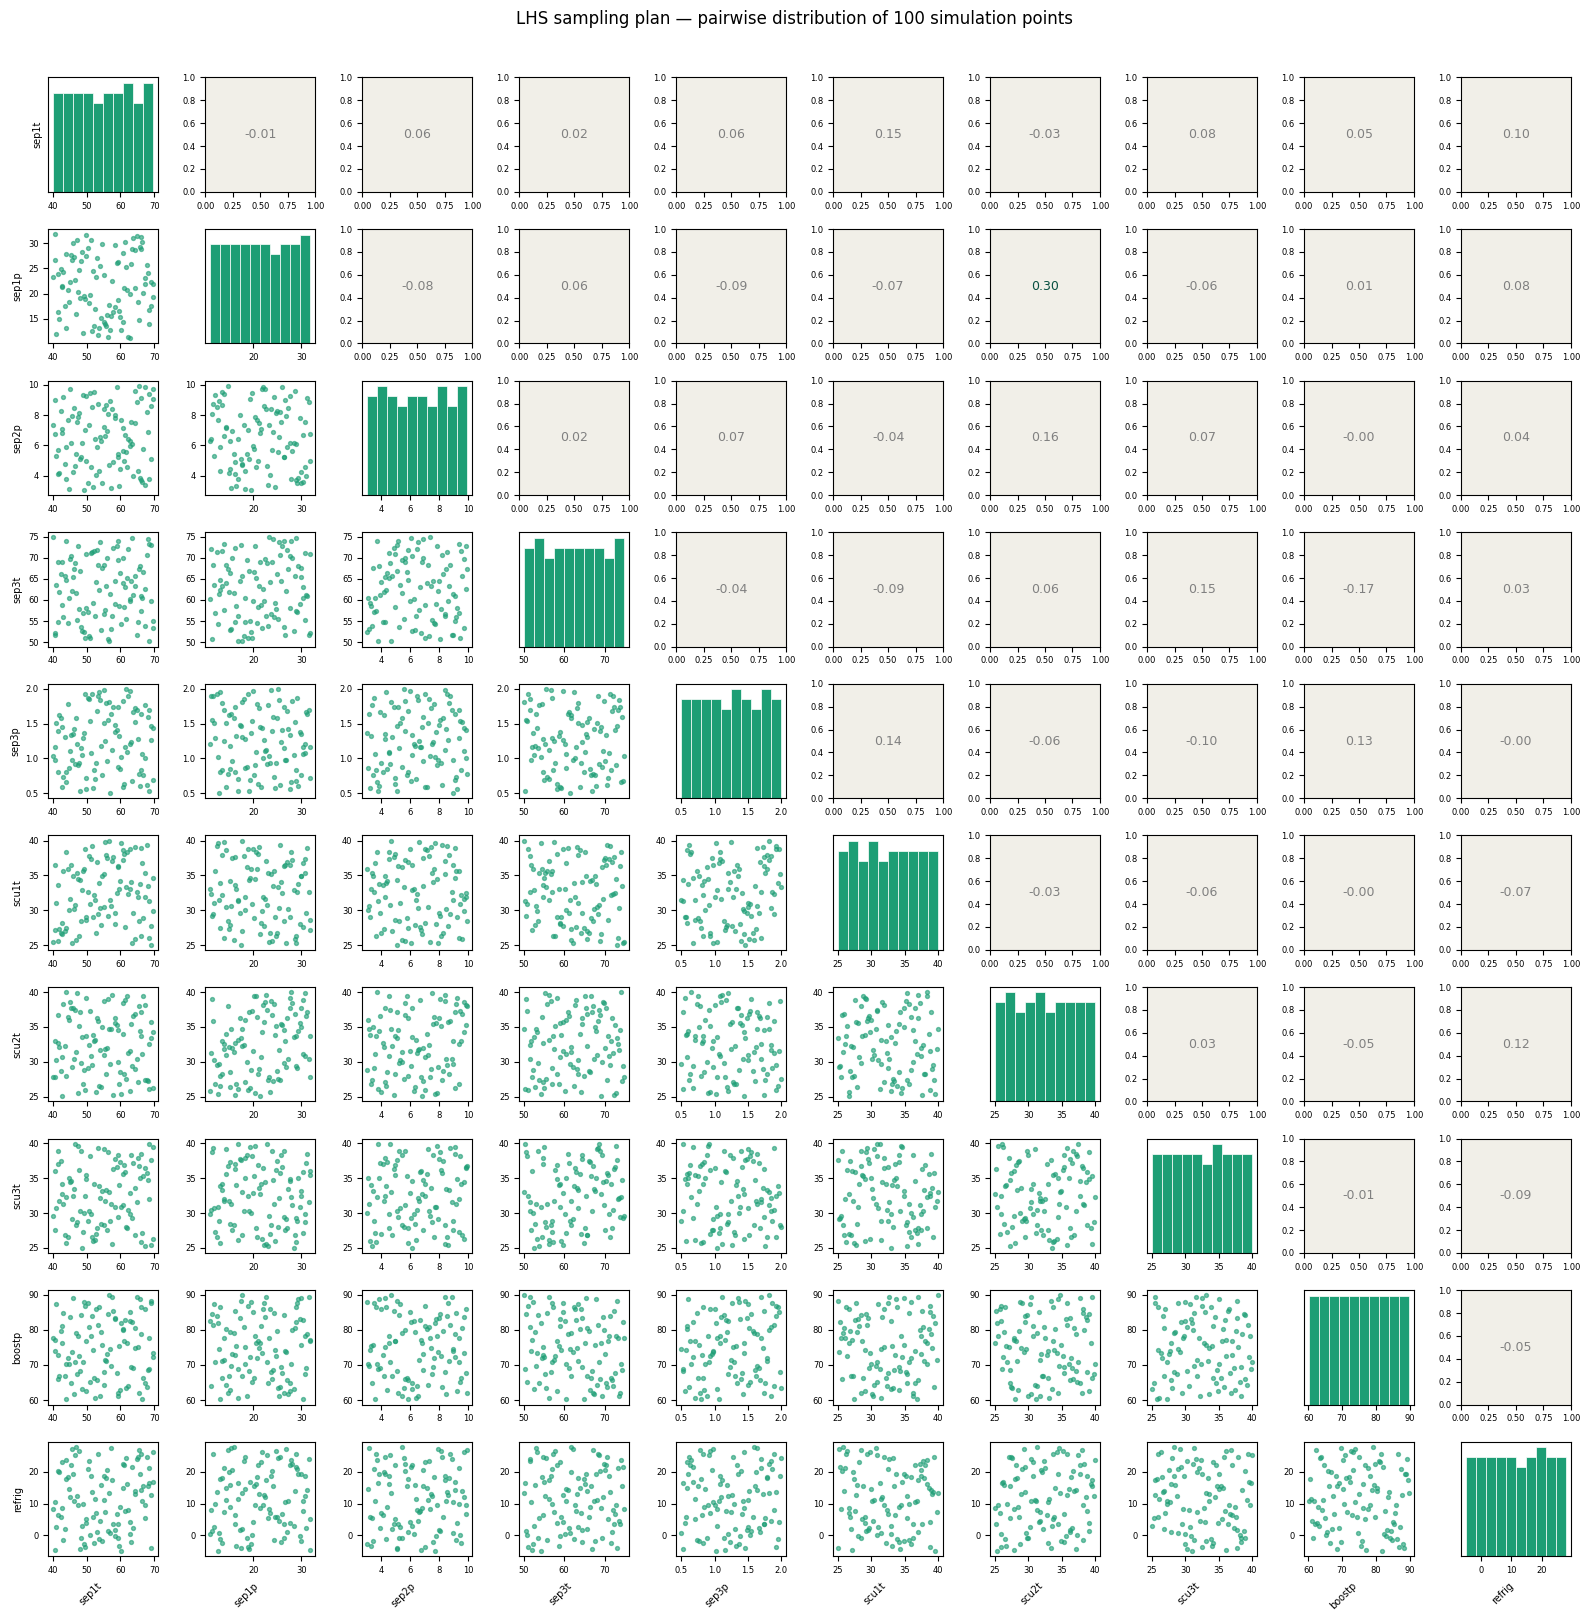

LHS plan statistics (should be close to uniform coverage):
        sep1t   sep1p   sep2p   sep3t   sep3p   scu1t   scu2t   scu3t  boostp  refrig
count  100.00  100.00  100.00  100.00  100.00  100.00  100.00  100.00  100.00  100.00
mean    55.00   21.49    6.50   62.50    1.25   32.50   32.50   32.50   75.02   11.49
std      8.70    6.09    2.03    7.26    0.44    4.35    4.35    4.35    8.70    9.59
min     40.11   11.10    3.06   50.16    0.50   25.09   25.06   25.01   60.23   -4.87
25%     47.66   16.26    4.76   56.27    0.88   28.81   28.77   28.85   67.57    3.39
50%     55.11   21.45    6.50   62.54    1.26   32.51   32.44   32.45   75.02   11.41
75%     62.35   26.68    8.25   68.76    1.63   36.23   36.24   36.18   82.51   19.56
max     69.73   31.81    9.94   74.83    2.00   40.00   39.98   39.93   89.77   27.82


In [8]:
# LHS Plan Visualization

fig, axes = plt.subplots(10, 10, figsize=(16, 16))
fig.suptitle("LHS sampling plan — pairwise distribution of 100 simulation points", 
             fontsize=12, y=1.01)

for i in range(10):
    for j in range(10):
        ax = axes[i, j]
        if i == j:
            # Diagonal: histogram of each variable
            ax.hist(X[:, i], bins=10, color="#1D9E75", edgecolor="white", linewidth=0.5)
            ax.set_yticks([])
        elif i > j:
            # Lower triangle: scatter plot of variable pair
            ax.scatter(X[:, j], X[:, i], s=8, alpha=0.6, color="#1D9E75")
        else:
            # Upper triangle: Pearson correlation coefficient
            corr = np.corrcoef(X[:, i], X[:, j])[0, 1]
            ax.text(0.5, 0.5, f"{corr:.2f}",
                    ha="center", va="center", fontsize=9,
                    color="#085041" if abs(corr) > 0.2 else "gray",
                    transform=ax.transAxes)
            ax.set_facecolor("#F1EFE8")

        # Labels only on edges
        if i == 9:
            ax.set_xlabel(cols_X[j], fontsize=7, rotation=45, ha="right")
        if j == 0:
            ax.set_ylabel(cols_X[i], fontsize=7)

        ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig(FIG_PATH + "lhs_sampling_plan.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics of the plan
print("LHS plan statistics (should be close to uniform coverage):")
print(pd.DataFrame(X, columns=cols_X).describe().round(2).to_string())

> **Interpreting the LHS statistics:** a well-constructed LHS plan should show 
> means close to the midpoint of each variable's range, and standard deviations 
> consistent with a uniform distribution: σ = (upper − lower) / √12. Both 
> conditions are satisfied here, confirming good coverage of the input space 
> before running any simulation.
>
> The coverage quality check below quantifies this: ratios close to 1.0 
> confirm that each variable is sampled uniformly across its full operating range.

In [9]:
# Verify coverage quality: compare observed std vs theoretical uniform std (desired ratio closed to 1)
print("\nCoverage quality check (observed std vs theoretical uniform std):")
print(f"{'Variable':>10}  {'Observed std':>13}  {'Theoretical':>12}  {'Ratio':>7}")
print("-" * 50)
for i, var in enumerate(cols_X):
    lo, hi = XLIMITS[i]
    theoretical_std = (hi - lo) / (12 ** 0.5)
    observed_std    = X[:, i].std()
    ratio           = observed_std / theoretical_std
    print(f"{var:>10}  {observed_std:>13.3f}  {theoretical_std:>12.3f}  {ratio:>7.3f}")


Coverage quality check (observed std vs theoretical uniform std):
  Variable   Observed std   Theoretical    Ratio
--------------------------------------------------
     sep1t          8.652         8.660    0.999
     sep1p          6.061         6.062    1.000
     sep2p          2.019         2.021    0.999
     sep3t          7.219         7.217    1.000
     sep3p          0.433         0.433    1.000
     scu1t          4.331         4.330    1.000
     scu2t          4.329         4.330    1.000
     scu3t          4.328         4.330    1.000
    boostp          8.654         8.660    0.999
    refrig          9.539         9.526    1.001


---
## 5. Dataset Generation — Simulation Loop <a id='5-dataset-generation'></a>

For each LHS sample, we:
1. Convert engineering units to DWSIM internal units (°C → K, bar-g → Pa)
2. Set the 10 input variables via `SetPropertyValue()`
3. Trigger the flowsheet solver via `CalculateFlowsheet2()`
4. If converged, read the two outputs: `crude_flow` (kmol/h) and `power` (kW)
5. If not converged after 2 attempts, reload the flowsheet and flag as failed

**Note on unit conversions:**
- Temperature: `T_K = T_C + 273.15`
- Gauge to absolute pressure: `P_Pa = (1.013 + P_barg) × 10⁵`
- For valves, a 0.5 bar offset is added to account for the pressure drop across the valve

**Note on power calculation:**  
Total power is the sum of the 4 compressors (23-KA-01, 23-KA-02, 23-KA-03, 27-KA-01) plus 
the export pump (21-PA-01). For 23-KA-01, we use `PROP_CO_3` (shaft power in kW) directly; 
for the others, `GetEnergyConsumption()` returns watts and we divide by 1000.

In [10]:
# ── Helper functions ──────────────────────────────────────────────────────────

def load_sim():
    """Load a fresh copy of the flowsheet. Called at startup and after failures."""
    return dwsim_net.LoadFlowsheet(SIM_FILE)

def set_inputs(fs, x):
    """
    Write the 10 operating variables to the flowsheet.
    All conversions from engineering units to DWSIM internal units happen here.
    """
    sep1t, sep1p, sep2p, sep3t, sep3p, scu1t, scu2t, scu3t, boostp, refrig = x

    # Feed stream pressure (PROP_MS_1 = pressure in Pa absolute)
    fs.GetFlowsheetSimulationObject("MSTR-01").SetPropertyValue(
        "PROP_MS_1", (1.013 + sep1p) * 1e5)

    # 1st separator inlet temperature via cooler outlet (PROP_HT_0 = outlet T in K)
    fs.GetFlowsheetSimulationObject("20-HA-01").SetPropertyValue(
        "PROP_HT_0", sep1t + 273.15)

    # Valve outlet pressures (PROP_VA_2 = outlet pressure in Pa absolute)
    # 0.5 bar offset accounts for the pressure drop across each valve
    fs.GetFlowsheetSimulationObject("VALV-01").SetPropertyValue(
        "PROP_VA_2", (1.013 + sep2p + 0.5) * 1e5)
    fs.GetFlowsheetSimulationObject("VALV-02").SetPropertyValue(
        "PROP_VA_2", (1.013 + sep3p + 0.5) * 1e5)

    # 3rd separator inlet temperature
    fs.GetFlowsheetSimulationObject("20-HA-03").SetPropertyValue(
        "PROP_HT_0", sep3t + 273.15)

    # Inter-stage cooler outlet temperatures (between compression stages)
    fs.GetFlowsheetSimulationObject("23-HA-01").SetPropertyValue(
        "PROP_HT_0", scu1t + 273.15)
    fs.GetFlowsheetSimulationObject("23-HA-02").SetPropertyValue(
        "PROP_HT_0", scu2t + 273.15)
    fs.GetFlowsheetSimulationObject("23-HA-03").SetPropertyValue(
        "PROP_HT_0", scu3t + 273.15)

    # Refrigeration cooler outlet temperature
    fs.GetFlowsheetSimulationObject("25-HA-02").SetPropertyValue(
        "PROP_HT_0", refrig + 273.15)

    # Export compressor outlet pressure (PROP_CO_0 = outlet pressure in Pa absolute)
    fs.GetFlowsheetSimulationObject("23-KA-01").SetPropertyValue(
        "PROP_CO_0", (1.013 + boostp) * 1e5)

def get_outputs(fs):
    """
    Read the two key performance indicators from a converged flowsheet.
    Returns: (crude_flow [kmol/h], total_power [kW])
    """
    # Crude oil flow: molar flow of stabilised crude product stream
    # PROP_MS_3 returns mol/s, multiply by 3.6 to convert to kmol/h
    crude = fs.GetFlowsheetSimulationObject("MSTR-22").GetPropertyValue("PROP_MS_3") * 3.6

    # Total compression + pumping power
    # 23-KA-01: PROP_CO_3 = shaft power in kW (direct)
    # Others: GetEnergyConsumption() returns W, divide by 1000
    p1 = fs.GetFlowsheetSimulationObject("23-KA-01").GetPropertyValue("PROP_CO_3")
    p2 = fs.GetFlowsheetSimulationObject("23-KA-02").GetEnergyConsumption() / 1000
    p3 = fs.GetFlowsheetSimulationObject("23-KA-03").GetEnergyConsumption() / 1000
    p4 = fs.GetFlowsheetSimulationObject("27-KA-01").GetEnergyConsumption() / 1000
    p5 = fs.GetFlowsheetSimulationObject("21-PA-01").GetEnergyConsumption() / 1000
    power = p1 + p2 + p3 + p4 + p5

    return crude, power


In [11]:
# ── Main simulation loop ──────────────────────────────────────────────────────
cols_Y = ["crude_flow_kmolh", "power_kW", "solved"]
rows   = []

fs = load_sim()
print("Flowsheet loaded. Starting simulation loop...\n")
print(f"{'#':>4}  {'sep1t':>6} {'boostp':>7}  {'crude':>10} {'power':>9}  {'t(s)':>5}  status")
print("-" * 70)

t_total = time.time()

for i, x in enumerate(X):
    t0 = time.time()
    try:
        set_inputs(fs, x)
        dwsim_net.CalculateFlowsheet2(fs)  # first solver attempt

        if not fs.Solved:
            dwsim_net.CalculateFlowsheet2(fs)  # second attempt if not converged

        if fs.Solved:
            crude, power = get_outputs(fs)
            rows.append(list(x) + [crude, power, 1])
            status = "OK"
        else:
            # Mark as failed and reload a clean flowsheet for next iteration
            crude, power = -9999, -9999
            rows.append(list(x) + [crude, power, 0])
            status = "FAIL"
            fs = load_sim()

    except Exception as e:
        crude, power = -9999, -9999
        rows.append(list(x) + [crude, power, 0])
        status = f"ERR: {str(e)[:30]}"
        fs = load_sim()  # reload after any unexpected error

    dt        = time.time() - t0
    elapsed   = time.time() - t_total
    avg       = elapsed / (i + 1)
    remaining = avg * (N_SAMPLES - i - 1)
    solved_so_far = sum(r[-1] for r in rows)

    print(f"{i+1:>4}  {x[0]:>6.1f} {x[8]:>7.1f}  "
          f"{crude:>10.1f} {power:>9.1f}  "
          f"{dt:>5.1f}s  {status}  "
          f"[{solved_so_far}/{i+1} | ~{remaining/60:.1f} min remaining]")

t_fin = time.time() - t_total
print(f"\nTotal time: {t_fin/60:.1f} min")

# ── Save dataset to CSV ───────────────────────────────────────────────────────
df = pd.DataFrame(rows, columns=cols_X + cols_Y)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nDataset saved to: {OUTPUT_CSV}")
print(f"Total: {len(df)}  |  Valid: {df['solved'].sum()}  |  Failed: {(df['solved']==0).sum()}")
print(df[["crude_flow_kmolh", "power_kW"]].describe().round(2))

Flowsheet loaded. Starting simulation loop...

   #   sep1t  boostp       crude     power   t(s)  status
----------------------------------------------------------------------
   1    51.8    74.4      2736.1    7043.0   17.2s  OK  [1/1 | ~28.3 min remaining]
   2    51.3    78.4      2763.7    5441.2   19.0s  OK  [2/2 | ~29.5 min remaining]
   3    68.6    69.0      2733.9    9783.3   17.5s  OK  [3/3 | ~28.9 min remaining]
   4    66.5    60.2      2757.1    5565.5   18.9s  OK  [4/4 | ~29.0 min remaining]
   5    67.2    64.9      2771.7    7381.3   15.8s  OK  [5/5 | ~28.0 min remaining]
   6    44.7    70.2      2743.3    9093.3   17.1s  OK  [6/6 | ~27.5 min remaining]
   7    46.1    61.8      2778.4    6182.6   16.8s  OK  [7/7 | ~27.1 min remaining]
   8    58.8    67.6      2774.4    6501.0   13.7s  OK  [8/8 | ~26.0 min remaining]
   9    63.2    69.6      2770.1    6572.1   12.2s  OK  [9/9 | ~25.0 min remaining]
  10    62.8    85.2      2788.4    8304.5   17.6s  OK  [10/10 | ~24

---
## 6. Exploratory Data Analysis (EDA) <a id='6-eda'></a>

Before training the surrogate, we explore the dataset to understand:
- The distribution of each output variable
- Which input variables have the strongest linear correlation with each output

This informs both the surrogate model choice and the interpretation of the optimization results.

Valid simulations: 100 / 100


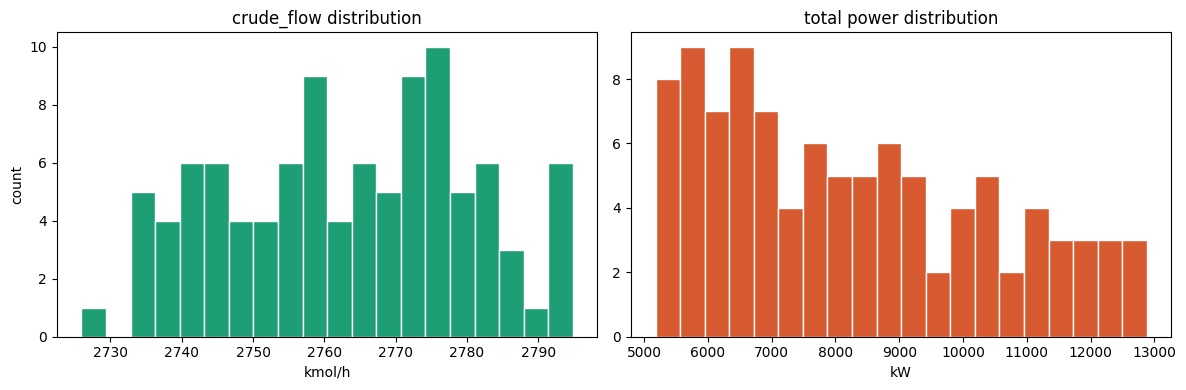

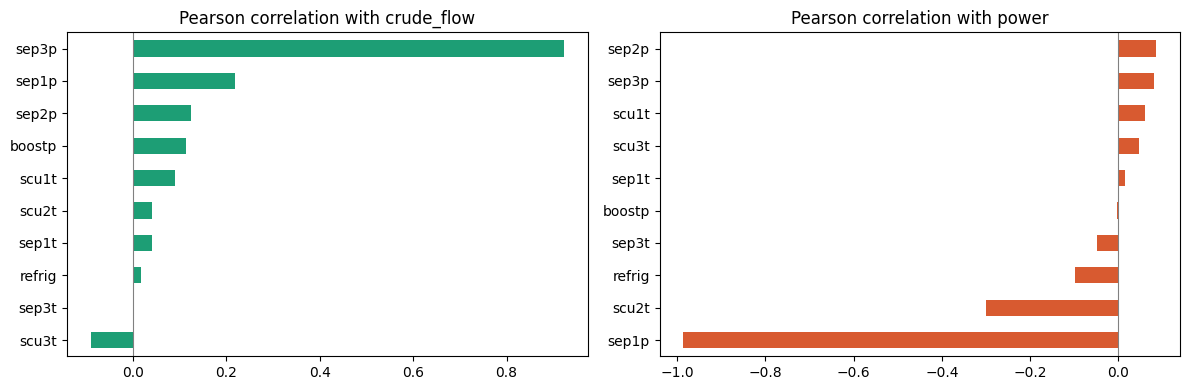

Correlations with crude_flow:
scu3t    -0.090
sep3t    -0.000
refrig    0.018
sep1t     0.041
scu2t     0.042
scu1t     0.091
boostp    0.113
sep2p     0.125
sep1p     0.219
sep3p     0.923
dtype: float64

Correlations with power:
sep1p    -0.986
scu2t    -0.299
refrig   -0.098
sep3t    -0.048
boostp   -0.003
sep1t     0.015
scu3t     0.048
scu1t     0.060
sep3p     0.080
sep2p     0.086
dtype: float64


In [12]:
# Load dataset (if running this section independently)
df = pd.read_csv(OUTPUT_CSV)

# Filter out failed simulations (marked with -9999)
df_clean = df[df["solved"] == 1].reset_index(drop=True)
print(f"Valid simulations: {len(df_clean)} / {len(df)}")

X_arr  = df_clean[cols_X].values
y_crude = df_clean["crude_flow_kmolh"].values
y_power = df_clean["power_kW"].values

# ── Output distributions ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_crude, bins=20, edgecolor="white", color="#1D9E75")
axes[0].set_title("crude_flow distribution")
axes[0].set_xlabel("kmol/h")
axes[0].set_ylabel("count")

axes[1].hist(y_power, bins=20, edgecolor="white", color="#D85A30")
axes[1].set_title("total power distribution")
axes[1].set_xlabel("kW")

plt.tight_layout()
plt.savefig(FIG_PATH + "eda_outputs.png", dpi=150)
plt.show()

# ── Linear correlations: inputs → outputs ────────────────────────────────────
# Note: these are Pearson correlations — they capture linear relationships only.
# The GPR will also capture non-linear effects.
X_df = df_clean[cols_X]
corr_crude = X_df.corrwith(df_clean["crude_flow_kmolh"]).sort_values()
corr_power = X_df.corrwith(df_clean["power_kW"]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

corr_crude.plot(kind="barh", ax=axes[0], color="#1D9E75")
axes[0].set_title("Pearson correlation with crude_flow")
axes[0].axvline(0, color="gray", linewidth=0.8)

corr_power.plot(kind="barh", ax=axes[1], color="#D85A30")
axes[1].set_title("Pearson correlation with power")
axes[1].axvline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.savefig(FIG_PATH + "eda_correlations.png", dpi=150)
plt.show()

print("Correlations with crude_flow:")
print(corr_crude.round(3))
print("\nCorrelations with power:")
print(corr_power.round(3))

## 7. Surrogate Model — Gaussian Process Regression (GPR / Kriging)

### What is GPR / Kriging?

Gaussian Process Regression (GPR), also known as Kriging in the geostatistics 
literature, is a non-parametric Bayesian regression method. Instead of fitting 
a fixed functional form, GPR defines a **probability distribution over functions** 
consistent with the observed data.

The key idea is that the correlation between two outputs depends on the distance 
between their inputs through a **kernel function** (also called covariance function):

$$k(x_i, x_j) = \exp\left(-\frac{1}{2} \sum_{d=1}^{D} \frac{(x_i^d - x_j^d)^2}{l_d^2}\right)$$

The $l_d$ parameters are the **length scales** — one per input variable. A small 
$l_d$ means the output is very sensitive to that variable; a large $l_d$ means 
the variable has little effect. This is called **ARD (Automatic Relevance 
Determination)** and gives us a built-in sensitivity analysis.

GPR also provides **prediction uncertainty** at any point — not just a predicted 
value but also a confidence interval, wider in regions with few training points.

### Why GPR? — model comparison

GPR is the method used in the original paper and the standard choice for surrogate 
modelling with small datasets (N ≈ 10×d). However, to validate this choice we 
compare it against four alternative regression algorithms on the same train/test 
split before committing to GPR.

A good surrogate should show:
- High R² on **test** data — rules out overfitting
- Low gap between train and test R² — confirms generalisation
- Practically negligible MAE relative to the output range

In [13]:
# ── Train / test split (80 / 20) ──────────────────────────────────────────────
X_train, X_test, yc_train, yc_test, yp_train, yp_test = train_test_split(
    X_arr, y_crude, y_power, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}\n")

# ── Feature scaling ───────────────────────────────────────────────────────────
# GPR with RBF kernel is sensitive to input scale.
# StandardScaler centers each variable to mean=0, std=1 so all variables
# are on the same scale and the length scales are comparable.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit on train only
X_test_s  = scaler.transform(X_test)       # apply same transform to test

# ── Kernel definition ─────────────────────────────────────────────────────────
# Composite ARD kernel: RBF with one length_scale per input dimension (10 total)
# - ConstantKernel: scales the overall output variance
# - RBF: main covariance structure — large length_scale = variable has low influence
# - WhiteKernel: accounts for numerical noise in simulator outputs
def make_kernel():
    return (
        ConstantKernel(1.0) *
        # length_scale=np.ones(10) passes an array of length 10 — one initial
        # value per input variable. This activates ARD: during fit(), each
        # length scale is optimised independently, revealing variable relevance.
        # Contrast with length_scale=1.0 (scalar), which would share one
        # length scale across all variables and disable ARD.
        RBF(length_scale=np.ones(10), length_scale_bounds=(1e-3, 1e8)) +
        WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1))
    )

# ── Model comparison ──────────────────────────────────────────────────────────
# Train a temporary GPR instance for comparison — the final model is trained
# separately in the next cell with full output and kernel inspection
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

def compare_models(y_train, y_test, output_name, unit):
    gpr_temp = GaussianProcessRegressor(
        kernel=make_kernel(), n_restarts_optimizer=10,
        normalize_y=True, random_state=42
    )
    models = {
        "GPR (Kriging)":       gpr_temp,
        "Gradient Boosting":   GradientBoostingRegressor(n_estimators=200, random_state=42),
        "Random Forest":       RandomForestRegressor(n_estimators=200, random_state=42),
        "Ridge Regression":    Ridge(alpha=1.0),
        "MLP Neural Network":  MLPRegressor(hidden_layer_sizes=(50, 50),
                                            max_iter=2000, random_state=42),
    }
    print(f"=== Model comparison — {output_name} ===")
    print(f"{'Model':>22}  {'Train R²':>9}  {'Test R²':>9}  {'Test MAE':>12}")
    print("-" * 62)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        for name, model in models.items():
            model.fit(X_train_s, y_train)
            y_tr = model.predict(X_train_s)
            y_te = model.predict(X_test_s)
            print(f"{name:>22}  {r2_score(y_train, y_tr):>9.4f}  "
                  f"{r2_score(y_test, y_te):>9.4f}  "
                  f"{mean_absolute_error(y_test, y_te):>9.2f} {unit}")
    print()

compare_models(yc_train, yc_test, "crude_flow", "kmol/h")
compare_models(yp_train, yp_test, "power", "kW")

Train: 80  |  Test: 20

=== Model comparison — crude_flow ===
                 Model   Train R²    Test R²      Test MAE
--------------------------------------------------------------
         GPR (Kriging)     0.9998     0.9998       0.22 kmol/h
     Gradient Boosting     1.0000     0.9406       3.59 kmol/h
         Random Forest     0.9877     0.8964       4.22 kmol/h
      Ridge Regression     0.9607     0.9204       3.88 kmol/h
    MLP Neural Network   -34.1315  -234.2608     229.67 kmol/h

=== Model comparison — power ===
                 Model   Train R²    Test R²      Test MAE
--------------------------------------------------------------
         GPR (Kriging)     0.9999     0.9998      21.20 kW
     Gradient Boosting     1.0000     0.9981      73.13 kW
         Random Forest     0.9993     0.9950     118.50 kW
      Ridge Regression     0.9758     0.9514     382.94 kW
    MLP Neural Network     0.9527     0.8751     629.10 kW



### Results interpretation

The comparison confirms that GPR is the appropriate choice for this dataset size:

**Overfitting in tree-based models:** Gradient Boosting and Random Forest achieve 
R² = 1.000 on the training set but drop significantly on test data (0.94 and 0.90 
for crude_flow). With only 80 training points in 10 dimensions, these models 
memorise the training data rather than learning the underlying response surface.

**Data starvation in neural networks:** the MLP fails completely (R² = −234 for 
crude_flow), confirming that neural networks require far more data than is available 
here. This is consistent with the observation from the process industry: 
*"the bottleneck is always data"* (Griffith, AspenTech, 2025).

**Why GPR generalises better:** GPR incorporates prior knowledge about the smoothness 
of the response surface through the kernel function. This acts as a strong regulariser 
that prevents overfitting even with very few training points — exactly the regime we 
are in with N = 100 simulations across 10 variables.

**Practical implication:** for surrogate modelling of process simulations where each 
data point is expensive to generate (~25 seconds per simulation here), GPR is the 
method of choice in the range N ≈ 10×d to 20×d. At larger dataset sizes (N > 1,000), 
gradient boosting becomes competitive and eventually preferable due to its 
O(N log N) scaling vs GPR's O(N³).

### Kernel choice

We use a composite kernel: `ConstantKernel × RBF + WhiteKernel`

- `ConstantKernel`: scales the overall output variance
- `RBF`: the main covariance structure with one length scale per input (ARD)
- `WhiteKernel`: accounts for numerical noise in the simulator outputs

`n_restarts_optimizer=10` re-runs hyperparameter optimisation from 10 random 
starting points to avoid local optima in the marginal likelihood maximisation.

> **Note on ConvergenceWarnings:** the GPR optimizer may warn that some length 
> scales are at their upper bound. This occurs for input variables with negligible 
> influence on the output — the model correctly assigns them very large length 
> scales (effectively ignoring them). The warnings are suppressed as they do not 
> affect model accuracy.

In [14]:
# ── Train final GPR for crude_flow ────────────────────────────────────────────
gpr_crude = GaussianProcessRegressor(
    kernel=make_kernel(),
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    gpr_crude.fit(X_train_s, yc_train)

print(f"Optimised kernel (crude_flow): {gpr_crude.kernel_}")

yc_pred_train = gpr_crude.predict(X_train_s)
yc_pred_test  = gpr_crude.predict(X_test_s)

print(f"\ncrude_flow — Train R²: {r2_score(yc_train, yc_pred_train):.4f}")
print(f"crude_flow — Test  R²: {r2_score(yc_test,  yc_pred_test):.4f}")
print(f"crude_flow — Test MAE: {mean_absolute_error(yc_test, yc_pred_test):.2f} kmol/h")

# ── Train final GPR for power ─────────────────────────────────────────────────
gpr_power = GaussianProcessRegressor(
    kernel=make_kernel(),
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    gpr_power.fit(X_train_s, yp_train)

yp_pred_train = gpr_power.predict(X_train_s)
yp_pred_test  = gpr_power.predict(X_test_s)

print(f"\npower — Train R²: {r2_score(yp_train, yp_pred_train):.4f}")
print(f"power — Test  R²: {r2_score(yp_test,  yp_pred_test):.4f}")
print(f"power — Test MAE: {mean_absolute_error(yp_test, yp_pred_test):.2f} kW")

Optimised kernel (crude_flow): 5.76**2 * RBF(length_scale=[2.06e+03, 11.3, 3.56, 1.28e+06, 6.33, 5.33e+05, 1.58e+06, 2.19e+06, 806, 2.95e+03]) + WhiteKernel(noise_level=0.000233)

crude_flow — Train R²: 0.9998
crude_flow — Test  R²: 0.9998
crude_flow — Test MAE: 0.22 kmol/h

power — Train R²: 0.9999
power — Test  R²: 0.9998
power — Test MAE: 21.20 kW


### ARD kernel interpretation — which variables matter?

One of the key advantages of GPR with an ARD (Automatic Relevance Determination) 
kernel is that the optimised length scales reveal the influence of each input 
variable on each output — essentially a built-in sensitivity analysis.

The relationship is inverse: a **small length scale** means the output changes 
significantly when that variable moves → high relevance. A **large length scale** 
means the output is nearly flat with respect to that variable → low relevance.

This information is extracted directly from the trained kernel without any 
additional computation.

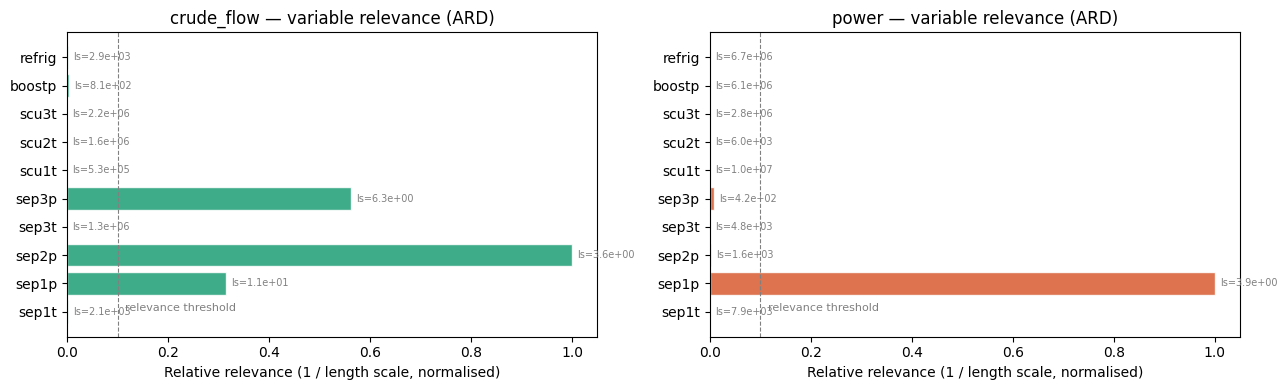

  Variable    LS (crude)    LS (power)  Crude rel.  Power rel.
     sep1t      2.06e+03      7.87e+03      0.002         0.000   
     sep1p      1.13e+01      3.87e+00      0.315***      1.000***
     sep2p      3.56e+00      1.58e+03      1.000***      0.002   
     sep3t      1.28e+06      4.82e+03      0.000         0.001   
     sep3p      6.33e+00      4.19e+02      0.563***      0.009   
     scu1t      5.33e+05      1.01e+07      0.000         0.000   
     scu2t      1.58e+06      5.99e+03      0.000         0.001   
     scu3t      2.19e+06      2.82e+06      0.000         0.000   
    boostp      8.06e+02      6.12e+06      0.004         0.000   
    refrig      2.95e+03      6.65e+06      0.001         0.000   
*** relevant variable (relative relevance > 0.1)


In [15]:
# ── ARD kernel interpretation — automatic variable relevance ──────────────────
# The optimised length scales reveal which variables influence each output.
# Small length scale → output is sensitive to that variable (high relevance)
# Large length scale → output is insensitive (variable effectively ignored)

ls_crude = gpr_crude.kernel_.k1.k2.length_scale
ls_power = gpr_power.kernel_.k1.k2.length_scale

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, ls, title, color in zip(
    axes,
    [ls_crude, ls_power],
    ["crude_flow — variable relevance (ARD)", "power — variable relevance (ARD)"],
    ["#1D9E75", "#D85A30"]
):
    # Plot inverse length scale (= relevance): larger bar = more influential variable
    relevance = 1.0 / ls
    relevance_norm = relevance / relevance.max()

    bars = ax.barh(cols_X, relevance_norm, color=color, alpha=0.85, edgecolor="white")
    ax.set_xlabel("Relative relevance (1 / length scale, normalised)")
    ax.set_title(title)
    ax.axvline(0.1, color="gray", linewidth=0.8, linestyle="--")
    ax.text(0.11, 0.02, "relevance threshold", fontsize=8,
            color="gray", transform=ax.get_yaxis_transform())

    # Annotate bars with raw length scale values
    for bar, l in zip(bars, ls):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"ls={l:.1e}", va="center", fontsize=7, color="gray")

plt.tight_layout()
plt.savefig(FIG_PATH + "ard_relevance.png", dpi=150)
plt.show()

# Print interpretation table
print("=" * 65)
print(f"{'Variable':>10}  {'LS (crude)':>12}  {'LS (power)':>12}  {'Crude rel.':>10}  {'Power rel.':>10}")
print("=" * 65)
for i, var in enumerate(cols_X):
    rel_c = 1 / ls_crude[i] / (1 / ls_crude).max()
    rel_p = 1 / ls_power[i] / (1 / ls_power).max()
    flag_c = "***" if rel_c > 0.1 else "   "
    flag_p = "***" if rel_p > 0.1 else "   "
    print(f"{var:>10}  {ls_crude[i]:>12.2e}  {ls_power[i]:>12.2e}  "
          f"{rel_c:>9.3f}{flag_c}  {rel_p:>9.3f}{flag_p}")
print("=" * 65)
print("*** relevant variable (relative relevance > 0.1)")

### Key findings from ARD analysis

**crude_flow** is governed by three variables:
- `sep2p` (rel. 1.000) and `sep3p` (rel. 0.563): separator pressures in stages 2 and 3 — 
  higher pressures retain more light components in the liquid phase, increasing crude recovery
- `sep1p` (rel. 0.315): 1st separator pressure also contributes, though less dominantly

> Note: the linear correlation analysis (EDA) ranked `sep3p` as the dominant variable 
> (r = 0.92), while the ARD kernel reveals `sep2p` as equally or more important. 
> This highlights a key advantage of GPR over simple correlation analysis: it captures 
> non-linear relationships that Pearson correlation misses.

**power** is governed almost exclusively by `sep1p` (rel. 1.000):
- Higher 1st stage pressure means gas exits at higher pressure, requiring less downstream 
  compression work — a near-perfectly linear relationship (r = −0.99 in the EDA)
- All other variables have negligible influence on total power consumption

**Variables with no relevance** (length scale > 10⁵): `sep1t`, `sep3t`, `scu1t`, `scu2t`, 
`scu3t`, `boostp`, `refrig` — the GPR has effectively learned to ignore these for both outputs. 
This is ARD acting as an automatic feature selection mechanism.

---
## 8. Validation — Parity Plots and Residual Analysis <a id='8-validation'></a>

The primary validation tool for surrogate models is the **parity plot**: predicted vs actual values. 
A perfect surrogate would have all points on the 45° diagonal. Deviations from the diagonal 
indicate prediction errors.

We also compute the **relative error** to assess practical accuracy — i.e., whether the surrogate 
is accurate enough to make meaningful operational decisions.

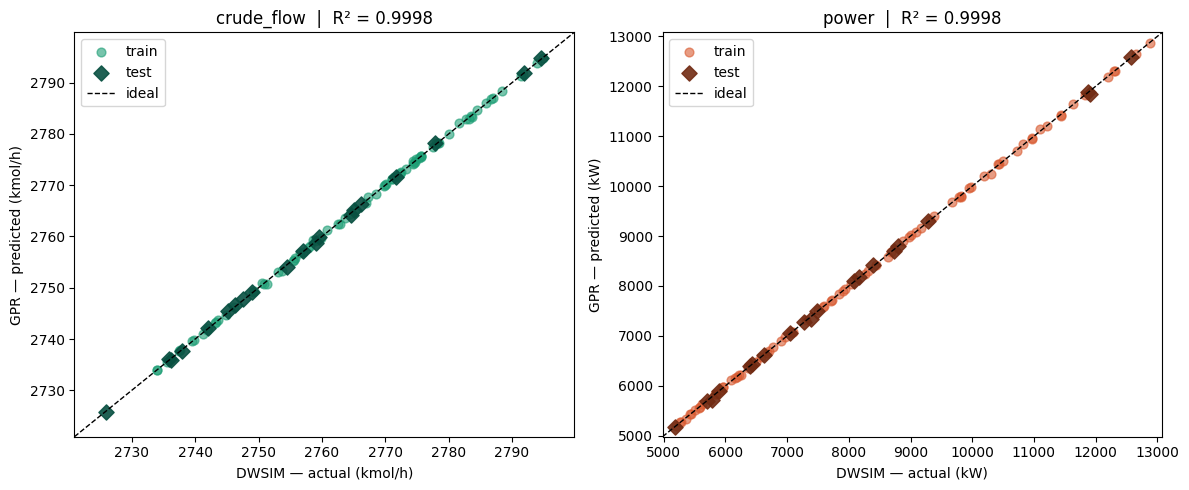

=== crude_flow ===
  Max absolute error : 0.51 kmol/h
  Mean absolute error: 0.22 kmol/h
  Mean relative error: 0.008%

=== power ===
  Max absolute error : 72.6 kW
  Mean absolute error: 21.2 kW
  Mean relative error: 0.272%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Parity plot: crude_flow ───────────────────────────────────────────────────
ax = axes[0]
ax.scatter(yc_train, yc_pred_train, alpha=0.6, color="#1D9E75", label="train", s=40)
ax.scatter(yc_test,  yc_pred_test,  alpha=0.9, color="#085041", label="test",  s=60, marker="D")
lim = [y_crude.min() - 5, y_crude.max() + 5]
ax.plot(lim, lim, "k--", linewidth=1, label="ideal")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("DWSIM — actual (kmol/h)")
ax.set_ylabel("GPR — predicted (kmol/h)")
ax.set_title(f"crude_flow  |  R² = {r2_score(yc_test, yc_pred_test):.4f}")
ax.legend()

# ── Parity plot: power ────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(yp_train, yp_pred_train, alpha=0.6, color="#D85A30", label="train", s=40)
ax.scatter(yp_test,  yp_pred_test,  alpha=0.9, color="#712B13", label="test",  s=60, marker="D")
lim2 = [y_power.min() - 200, y_power.max() + 200]
ax.plot(lim2, lim2, "k--", linewidth=1, label="ideal")
ax.set_xlim(lim2); ax.set_ylim(lim2)
ax.set_xlabel("DWSIM — actual (kW)")
ax.set_ylabel("GPR — predicted (kW)")
ax.set_title(f"power  |  R² = {r2_score(yp_test, yp_pred_test):.4f}")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_PATH + "parity_plots.png", dpi=150)
plt.show()

# ── Residual summary ──────────────────────────────────────────────────────────
print("=== crude_flow ===")
res_c = yc_test - yc_pred_test
print(f"  Max absolute error : {np.abs(res_c).max():.2f} kmol/h")
print(f"  Mean absolute error: {np.abs(res_c).mean():.2f} kmol/h")
print(f"  Mean relative error: {(np.abs(res_c) / yc_test * 100).mean():.3f}%")

print("\n=== power ===")
res_p = yp_test - yp_pred_test
print(f"  Max absolute error : {np.abs(res_p).max():.1f} kW")
print(f"  Mean absolute error: {np.abs(res_p).mean():.1f} kW")
print(f"  Mean relative error: {(np.abs(res_p) / yp_test * 100).mean():.3f}%")

### Residual analysis — practical accuracy assessment

R² alone can be misleading for very accurate models. The residual analysis below 
provides more actionable metrics:

- **Max absolute error**: the worst-case prediction error across all test points
- **Mean absolute error (MAE)**: average prediction error — the most interpretable metric
- **Mean relative error**: MAE expressed as a percentage of the actual value — 
  allows comparison across outputs with different scales

For operational use, the relevant question is: *is the surrogate accurate enough 
to make meaningful decisions?* The code cell above reports these metrics numerically. 
Both surrogates should show relative errors well below 1%, which is sufficient for 
optimisation and operational decision support.

The original paper (Andreasen, 2020) benchmarks DWSIM against HYSYS and reports 
R² > 0.99 across 91 converged simulations (Table 6). Our surrogate models exceed 
this benchmark against DWSIM itself, and our dataset achieves 100/100 convergence 
vs the paper's 91/100.

---
## 9. Optimization with NSGA-II <a id='9-optimization'></a>

### Problem formulation

We solve a **bi-objective optimization** problem:

$$\max_{x} \; \text{crude\_flow}(x) \qquad \text{and} \qquad \min_{x} \; \text{power}(x)$$

subject to: $x \in [x^L, x^U]$ (same bounds used to generate the training data)

The surrogate evaluates both objectives in microseconds, making it practical to run an 
evolutionary algorithm with population sizes and generation counts that would be infeasible 
with direct DWSIM calls.

### Why NSGA-II?

NSGA-II (Non-dominated Sorting Genetic Algorithm II) is the standard algorithm for multi-objective 
optimization in process engineering. It maintains a population of candidate solutions and evolves 
them using genetic operators (crossover, mutation) while sorting by Pareto dominance.

### Important note on bounds

The optimization bounds **must match the LHS sampling bounds exactly**. The GPR was only trained 
on data within those bounds — predictions outside that region are extrapolations and are not reliable.

In [19]:
from pymoo.core.callback import Callback

class OilGasProblem(Problem):
    """
    Inheriting from pymoo's Problem class (rather than using FunctionalProblem)
    allows vectorised evaluation: the entire population is passed as a matrix
    X of shape (pop_size, 10) in a single call, leveraging GPR batch prediction
    and significantly reducing overhead vs candidate-by-candidate evaluation.

    Bi-objective optimization problem for the oil & gas separation plant.

    Objectives:
        f1 = -crude_flow  (negated because NSGA-II minimizes)
        f2 =  power       (minimized directly)

    Decision variables: the 10 operating conditions (same bounds as LHS)
    """
    def __init__(self, gpr_crude, gpr_power, scaler):
        xl = np.array([40, 11,  3, 50, 0.5, 25, 25, 25, 60,  -5])
        xu = np.array([70, 32, 10, 75, 2.0, 40, 40, 40, 90,  28])
        super().__init__(n_var=10, n_obj=2, n_ieq_constr=0, xl=xl, xu=xu)
        self.gpr_crude = gpr_crude
        self.gpr_power = gpr_power
        self.scaler    = scaler

    def _evaluate(self, X, out, *args, **kwargs):
        # Scale inputs using the same scaler fitted on training data
        X_s = self.scaler.transform(X)
        crude = self.gpr_crude.predict(X_s)
        power = self.gpr_power.predict(X_s)
        # pymoo minimizes both objectives
        out["F"] = np.column_stack([-crude, power])


# ── History callback — records best objectives at each generation ─────────────
# Used to visualise convergence and the evolution of the Pareto front
class HistoryCallback(Callback):
    def __init__(self):
        super().__init__()
        self.data["best_crude"] = []   # best (max) crude_flow per generation
        self.data["best_power"] = []   # best (min) power per generation
        self.data["n_gen"]      = []   # generation index

    def notify(self, algorithm):
        F = algorithm.pop.get("F")
        self.data["best_crude"].append(-F[:, 0].min())  # undo negation
        self.data["best_power"].append( F[:, 1].min())
        self.data["n_gen"].append(algorithm.n_gen)


# ── Algorithm configuration ───────────────────────────────────────────────────
problem  = OilGasProblem(gpr_crude, gpr_power, scaler)
callback = HistoryCallback()

algorithm = NSGA2(
    pop_size=200,                      # 200 individuals — computationally free with GPR surrogate;
                                       # provides good Pareto front resolution. In direct simulation
                                       # this would multiply wall-clock time by 200×.
    sampling=FloatRandomSampling(),    # initialise with random feasible solutions
    crossover=SBX(prob=0.9, eta=15),   # Simulated Binary Crossover
    mutation=PM(eta=20),               # Polynomial Mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 300)  # run for 300 generations

# ── Run optimisation ──────────────────────────────────────────────────────────
print("Running NSGA-II...")
res = minimize(
    problem,
    algorithm,
    termination,
    seed=42,
    verbose=False,
    callback=callback                  # attach history callback
)

# ── Extract Pareto front results ──────────────────────────────────────────────
crude_pareto = -res.F[:, 0]   # undo the negation
power_pareto =  res.F[:, 1]
X_pareto     =  res.X

print(f"Optimization complete. Pareto front solutions: {len(res.F)}")
print(f"\ncrude_flow range: [{crude_pareto.min():.1f}, {crude_pareto.max():.1f}] kmol/h")
print(f"power range:      [{power_pareto.min():.1f}, {power_pareto.max():.1f}] kW")

Running NSGA-II...
Optimization complete. Pareto front solutions: 200

crude_flow range: [2806.4, 2807.3] kmol/h
power range:      [5038.6, 5055.2] kW


> **Note on Pareto front size:** all 200 solutions in the final population are 
> non-dominated, so the entire population forms the Pareto front. This happens 
> because `crude_flow` and `power` are controlled by largely independent variables 
> — improving one does not require worsening the other, so almost no solution 
> dominates another. In a problem with a strong trade-off (both objectives driven 
> by the same variable), the Pareto front would contain far fewer, well-separated 
> solutions.

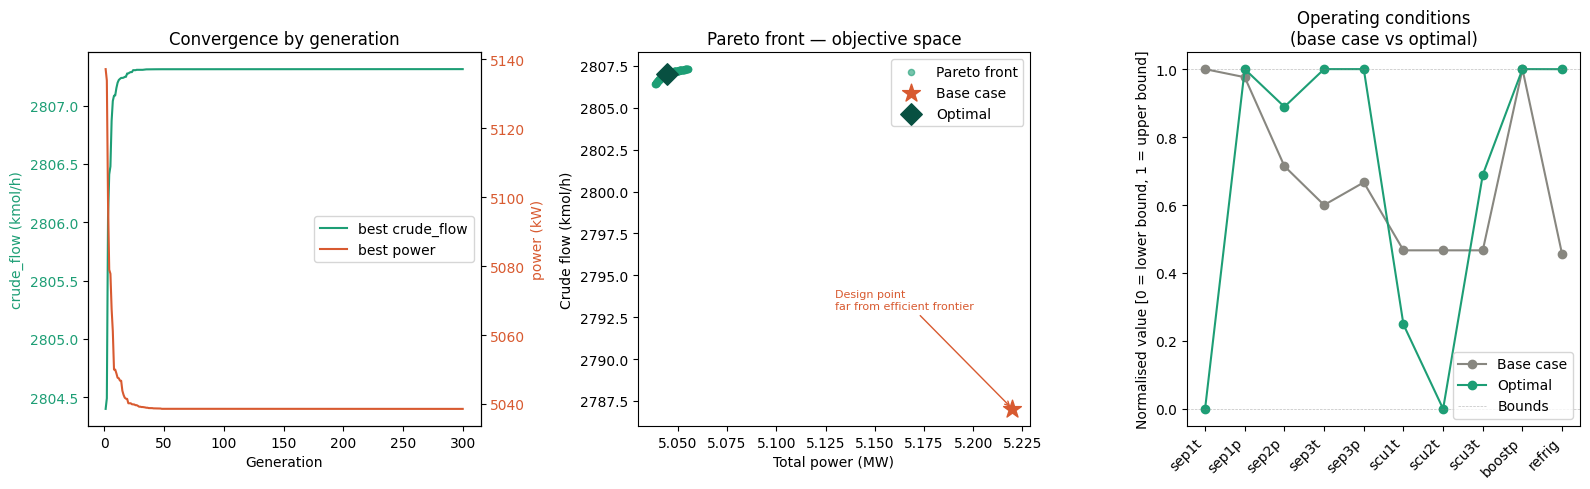

In [23]:
# ── Base case and optimal point ───────────────────────────────────────────────
# Defined here so this cell is self-contained and independent of Section 10.
# Section 10 reuses these same variables without recalculating them.

# Base case operating conditions from Andreasen (2022), Table 1
caso_base   = np.array([70.0, 31.5, 8.0, 65.0, 1.5, 32.0, 32.0, 32.0, 90.0, 10.0])
caso_base_s = scaler.transform(caso_base.reshape(1, -1))
crude_base  = gpr_crude.predict(caso_base_s)[0]
power_base  = gpr_power.predict(caso_base_s)[0]

# Optimal point: Pareto solution closest to the ideal point (max crude, min power)
# We normalise both objectives to [0, 1] and minimise the Euclidean distance
# to the ideal corner (crude_norm=1, power_norm=0)
crude_norm = (crude_pareto - crude_pareto.min()) / (crude_pareto.max() - crude_pareto.min())
power_norm = (power_pareto - power_pareto.min()) / (power_pareto.max() - power_pareto.min())
idx_best   = np.argmin(np.sqrt((1 - crude_norm)**2 + power_norm**2))
x_opt      = X_pareto[idx_best]
crude_opt  = crude_pareto[idx_best]
power_opt  = power_pareto[idx_best]

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: convergence by generation ───────────────────────────────────────
# Shows how the best crude_flow and best power evolve across generations.
# Both objectives converge quickly (before generation ~50), confirming that
# 300 generations is more than sufficient for this problem.
gens       = callback.data["n_gen"]
best_crude = callback.data["best_crude"]
best_power = callback.data["best_power"]

ax       = axes[0]
ax_twin  = ax.twinx()   # second y-axis for power (different scale)

l1, = ax.plot(gens, best_crude, color="#1D9E75", linewidth=1.5, label="best crude_flow")
l2, = ax_twin.plot(gens, best_power, color="#D85A30", linewidth=1.5, label="best power")

ax.set_xlabel("Generation")
ax.set_ylabel("crude_flow (kmol/h)", color="#1D9E75")
ax_twin.set_ylabel("power (kW)", color="#D85A30")
ax.set_title("Convergence by generation")
ax.tick_params(axis="y", labelcolor="#1D9E75")
ax_twin.tick_params(axis="y", labelcolor="#D85A30")
ax.legend([l1, l2], [l1.get_label(), l2.get_label()], loc="center right")

# ── Panel 2: Pareto front in objective space ──────────────────────────────────
# Each point is a non-dominated solution — no other solution is better in
# both objectives simultaneously. The base case sits far from the efficient
# frontier, showing significant room for improvement in both objectives.
ax = axes[1]

# Pareto front solutions
ax.scatter(power_pareto / 1000, crude_pareto,
           s=20, alpha=0.6, color="#1D9E75", label="Pareto front")

# Base case — design operating point from the paper
ax.scatter(power_base / 1000, crude_base,
           s=180, color="#D85A30", marker="*", zorder=5, label="Base case")

# Selected optimal point (minimum distance to ideal)
ax.scatter(power_opt / 1000, crude_opt,
           s=120, color="#085041", marker="D", zorder=5, label="Optimal")

# Annotation highlighting that the base case is far from the efficient frontier
ax.annotate(
    "Design point\nfar from efficient frontier",
    xy=(power_base / 1000, crude_base),
    xytext=(5.13, 2793),
    fontsize=8, color="#D85A30",
    arrowprops=dict(arrowstyle="->", color="#D85A30", lw=1)
)

ax.set_xlabel("Total power (MW)")
ax.set_ylabel("Crude flow (kmol/h)")
ax.set_title("Pareto front — objective space")
ax.legend()

# ── Panel 3: operating conditions — base case vs optimal ─────────────────────
# Each variable is normalised to [0, 1] using the LHS bounds.
# 0 = lower bound, 1 = upper bound.
# The optimal pushes pressure variables to their upper bounds and
# temperature variables to their lower bounds — consistent with the
# physical interpretation from the ARD and EDA analysis.
ax = axes[2]

xl_arr = np.array([40, 11,  3, 50, 0.5, 25, 25, 25, 60,  -5])
xu_arr = np.array([70, 32, 10, 75, 2.0, 40, 40, 40, 90,  28])

base_norm = (caso_base - xl_arr) / (xu_arr - xl_arr)
opt_norm  = (x_opt     - xl_arr) / (xu_arr - xl_arr)

x_idx = np.arange(len(cols_X))
ax.plot(x_idx, base_norm, "o-", color="#888780", linewidth=1.5, markersize=6, label="Base case")
ax.plot(x_idx, opt_norm,  "o-", color="#1D9E75", linewidth=1.5, markersize=6, label="Optimal")

# Reference lines at bounds
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.5, label="Bounds")
ax.axhline(1, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

ax.set_xticks(x_idx)
ax.set_xticklabels(cols_X, rotation=45, ha="right")
ax.set_ylabel("Normalised value [0 = lower bound, 1 = upper bound]")
ax.set_title("Operating conditions\n(base case vs optimal)")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_PATH + "optimization_results.png", dpi=150)
plt.show()

---
## 10. Results — Base Case vs Optimal Operating Conditions <a id='10-results'></a>

We compare the **base case** (design operating conditions from Andreasen (2022), Table 1) 
against the **optimal point** selected from the Pareto front using the minimum-distance-to-ideal 
criterion: the point that simultaneously maximises crude recovery and minimises power consumption, 
normalised to give equal weight to both objectives.

### Reference values from the paper

The base case operating conditions are taken from **Table 1** of Andreasen (2022). 
The expected outputs at these conditions are reported in **Table 5** of the same paper:

| Output | HYSYS | DWSIM (Andreasen 2022, v6.7.0) |
|---|---|---|
| Liquid export (kmol/h) | 2764.3 | 2763.0 |
| Liquid export MW (kg/kmole) | 201.9 | 201.9 |
| Liquid export RVP (psia) | 10.1 | 10.1 |

The surrogate prediction at the base case conditions serves as an implicit validation check: 
a value close to 2763.0 kmol/h confirms the surrogate is correctly calibrated.

> **Note on simulator version:** the reference values above were obtained with DWSIM v6.7.0. 
> This notebook uses DWSIM v9.0.5. Minor differences in the surrogate prediction vs the 
> reference values may reflect version-specific differences in the simulator rather than 
> surrogate error.

> **Note on interpolation:** all 10 base case conditions fall within the LHS sampling bounds 
> (Andreasen 2022, Table 3), so the surrogate prediction at this point is a reliable 
> interpolation, not an extrapolation.

In [24]:
# ── Base case operating conditions from Andreasen (2022), Table 1 ─────────────
# These are the design operating conditions of the reference plant.
# Source: Andreasen, A. (2022). Periodica Polytechnica Chem. Eng., 66(3), pp. 503–511. Table 1.
# Note: Andreasen (2022) uses DWSIM v6.7.0; this notebook uses v9.0.5.
# Note: only the 10 variables used in the parametric study are included here.
# Additional fixed settings (oil export pump pressure, gas export temperature, 
# etc.) are not varied and remain at their design values in the simulation.

base_case_dict = {
    "sep1t":  70.0,   # TSep1   — 20-HA-01 outlet [°C]
    "sep1p":  31.5,   # PSep1   — 20-VA-01 [bar-g]
    "sep2p":   8.0,   # PSep2   — 20-VA-02 [bar-g]
    "sep3t":  65.0,   # TSep3   — 20-HA-03 outlet [°C]
    "sep3p":   1.5,   # PSep3   — 20-VA-03 [bar-g]
    "scu1t":  32.0,   # TScrub1 — 23-HA-01 outlet [°C]
    "scu2t":  32.0,   # TScrub2 — 23-HA-02 outlet [°C]
    "scu3t":  32.0,   # TScrub3 — 23-HA-03 outlet [°C]
    "boostp": 90.0,   # PComp1  — 23-KA-01 outlet [bar-g]
    "refrig": 10.0,   # Trefrig — 25-HA-02 outlet [°C]
}

caso_base = np.array([base_case_dict[v] for v in cols_X])

print("Base case operating conditions (Andreasen 2022, Table 1):")
print(f"{'Variable':>10}  {'Value':>8}  {'Unit':>6}")
print("-" * 30)
for var, val in base_case_dict.items():
    unit = "°C" if var.endswith("t") or var == "refrig" else "bar-g"
    print(f"{var:>10}  {val:>8.1f}  {unit:>6}")

Base case operating conditions (Andreasen 2020, Table 1):
  Variable     Value    Unit
------------------------------
     sep1t      70.0      °C
     sep1p      31.5   bar-g
     sep2p       8.0   bar-g
     sep3t      65.0      °C
     sep3p       1.5   bar-g
     scu1t      32.0      °C
     scu2t      32.0      °C
     scu3t      32.0      °C
    boostp      90.0   bar-g
    refrig      10.0      °C


                           Base case       Optimal
   crude_flow (kmol/h)        2787.0        2807.0
            power (kW)        5219.9        5044.5
          Δ crude_flow                      +20.0
               Δ power                     -175.4
crude_flow improvement                     +0.72%
         energy saving                     +3.36%

=== OPTIMAL OPERATING CONDITIONS ===
  Variable   Base case     Optimal         Δ
----------------------------------------------
     sep1t       70.00       40.00    -30.00
     sep1p       31.50       32.00     +0.50
     sep2p        8.00        9.22     +1.22
     sep3t       65.00       75.00    +10.00
     sep3p        1.50        2.00     +0.50
     scu1t       32.00       28.73     -3.27
     scu2t       32.00       25.00     -7.00
     scu3t       32.00       35.34     +3.34
    boostp       90.00       90.00     -0.00
    refrig       10.00       27.99    +17.99


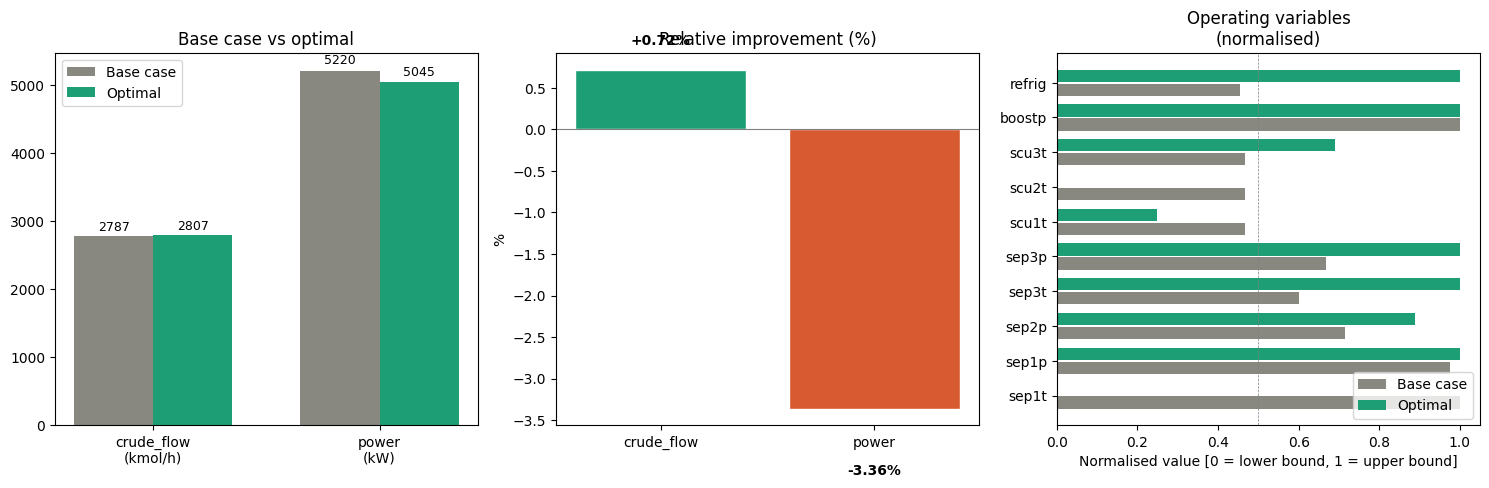

In [25]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 58)
print(f"{'':>22}  {'Base case':>12}  {'Optimal':>12}")
print("=" * 58)
print(f"{'crude_flow (kmol/h)':>22}  {crude_base:>12.1f}  {crude_opt:>12.1f}")
print(f"{'power (kW)':>22}  {power_base:>12.1f}  {power_opt:>12.1f}")
print("=" * 58)
print(f"{'Δ crude_flow':>22}  {'':>12}  {crude_opt - crude_base:>+11.1f}")
print(f"{'Δ power':>22}  {'':>12}  {power_opt - power_base:>+11.1f}")
print(f"{'crude_flow improvement':>22}  {'':>12}  {(crude_opt/crude_base - 1)*100:>+10.2f}%")
print(f"{'energy saving':>22}  {'':>12}  {(1 - power_opt/power_base)*100:>+10.2f}%")
print("=" * 58)

print("\n=== OPTIMAL OPERATING CONDITIONS ===")
print(f"{'Variable':>10}  {'Base case':>10}  {'Optimal':>10}  {'Δ':>8}")
print("-" * 46)
for i, var in enumerate(cols_X):
    delta = x_opt[i] - caso_base[i]
    print(f"{var:>10}  {caso_base[i]:>10.2f}  {x_opt[i]:>10.2f}  {delta:>+8.2f}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: absolute values comparison ──────────────────────────────────────
categories = ["crude_flow\n(kmol/h)", "power\n(kW)"]
x_pos = np.arange(len(categories))
w = 0.35
ax = axes[0]
bars1 = ax.bar(x_pos - w/2, [crude_base, power_base], w, label="Base case", color="#888780")
bars2 = ax.bar(x_pos + w/2, [crude_opt,  power_opt],  w, label="Optimal",   color="#1D9E75")
ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.set_title("Base case vs optimal")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=9)

# ── Panel 2: relative improvements ───────────────────────────────────────────
# pad=18 in set_title avoids overlap between bar labels and title
improvements = [(crude_opt/crude_base - 1)*100, (power_opt/power_base - 1)*100]
colors = ["#1D9E75" if v > 0 else "#D85A30" for v in improvements]
ax2 = axes[1]
bars = ax2.bar(["crude_flow", "power"], improvements, color=colors, edgecolor="white")
ax2.axhline(0, color="gray", linewidth=0.8)
ax2.set_title("Relative improvement (%)", pad=18)
ax2.set_ylabel("%")
for bar, val in zip(bars, improvements):
    # Positive label: small offset above bar; negative label: centred inside bar
    if val > 0:
        y_pos, va, color = val + 0.1, "bottom", "#085041"
    else:
        y_pos, va, color = val / 2, "center", "white"
    ax2.text(bar.get_x() + bar.get_width()/2, y_pos,
             f"{val:+.2f}%", ha="center", va=va, fontsize=10,
             fontweight="bold", color=color)

# ── Panel 3: normalised operating variables ───────────────────────────────────
# Variables at their lower bound (norm=0) would be invisible as zero-length bars.
# Dot markers at each bar tip ensure zero-value variables remain visible.
xl_arr = np.array([40, 11,  3, 50, 0.5, 25, 25, 25, 60,  -5])
xu_arr = np.array([70, 32, 10, 75, 2.0, 40, 40, 40, 90,  28])
base_norm = (caso_base - xl_arr) / (xu_arr - xl_arr)
opt_norm  = (x_opt     - xl_arr) / (xu_arr - xl_arr)

x_idx = np.arange(len(cols_X))
ax3 = axes[2]
ax3.barh(x_idx - 0.2, base_norm, 0.35, label="Base case", color="#888780")
ax3.barh(x_idx + 0.2, opt_norm,  0.35, label="Optimal",   color="#1D9E75")

# Dot markers at bar tips — ensures zero-value bars are still visible
for xi, (b, o) in enumerate(zip(base_norm, opt_norm)):
    ax3.plot(b, xi - 0.2, "o", color="#888780", markersize=5, zorder=5)
    ax3.plot(o, xi + 0.2, "o", color="#1D9E75", markersize=5, zorder=5)

ax3.set_yticks(x_idx)
ax3.set_yticklabels(cols_X)
ax3.set_xlabel("Normalised value [0 = lower bound, 1 = upper bound]")
ax3.set_title("Operating variables\n(normalised)")
ax3.legend(loc="lower right")
ax3.axvline(0, color="#333", linewidth=0.8)       # visible zero line
ax3.axvline(0.5, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig(FIG_PATH + "results_comparison.png", dpi=150)
plt.show()

### Results interpretation

The surrogate-based optimisation identifies operating conditions that simultaneously 
improve both objectives relative to the design base case.

**Crude oil recovery:**  
The optimal conditions push `sep3p` and `sep2p` towards the upper end of their ranges. 
Higher separator pressures in stages 2 and 3 retain more light hydrocarbon components 
in the liquid phase during flash separation, directly increasing the molar flow of 
stabilised crude to export. The ARD analysis confirmed these two variables as the 
dominant drivers of crude recovery — a result that was not fully apparent from the 
linear Pearson correlation alone, which ranked `sep3p` first but underestimated `sep2p`.

**Energy consumption:**  
The optimal conditions set `sep1p` at its maximum and the inter-stage cooling 
temperatures (`scu1t`, `scu2t`, `scu3t`) at their minimum. Higher 1st separator 
pressure means flash gas exits already at high pressure, reducing the compression 
ratio required in all downstream stages. Lower inter-stage temperatures reduce gas 
specific volume before each compressor, further reducing shaft work. The ARD analysis 
confirmed `sep1p` as the overwhelmingly dominant variable for power (relative relevance 
1.000), consistent with the near-perfect linear correlation (r = -0.99) seen in the EDA.

**Why both objectives improve simultaneously:**  
The key physical insight is that `crude_flow` and `power` are controlled by largely 
independent variables — separator stage pressures for recovery, 1st separator pressure 
for energy. This means there is no fundamental engineering trade-off between the two 
objectives within the operating ranges studied. The NSGA-II Pareto front reflects this: 
solutions cluster tightly near the simultaneous optimum rather than spreading across a 
broad trade-off curve.

**Comparison with Andreasen (2022):**  
Andreasen (2022) reports a base case liquid export of 2763.0 kmol/h in DWSIM v6.7.0 (Table 5). 
The surrogate prediction at the base case conditions should match this closely, confirming 
that the surrogate is well-calibrated against the reference simulation state. Any deviation 
above ~1% would indicate either a data coverage issue or a surrogate extrapolation artefact.

**Computational advantage:**  
NSGA-II performed 60,000 function evaluations (200 population × 300 generations). 
At ~25 seconds per DWSIM simulation, running the same search directly would take 
approximately **17 days**. With the GPR surrogate it completes in minutes — this is 
the core value proposition of surrogate-based optimisation for process engineering.

### Surrogate verification at the optimal point

The optimal conditions were identified by the surrogate — not by DWSIM directly. 
To close the loop, we run one final DWSIM simulation at the optimal conditions 
to verify that the surrogate prediction is accurate at this specific point.

This is the critical validation step for surrogate-based optimisation: a model 
that interpolates well across the training set (R² = 0.9998) but fails at the 
optimum would not be trustworthy for operational use.

In [26]:
# ── Verification: run DWSIM at the optimal conditions ────────────────────────
# The optimal conditions were found by the surrogate — we now verify them
# against the rigorous simulator to confirm the prediction is accurate.

set_inputs(fs, x_opt)
dwsim_net.CalculateFlowsheet2(fs)

if fs.Solved:
    crude_verified, power_verified = get_outputs(fs)
    print(f"Surrogate prediction: crude={crude_opt:.1f} kmol/h, power={power_opt:.1f} kW")
    print(f"DWSIM verification:   crude={crude_verified:.1f} kmol/h, power={power_verified:.1f} kW")
    print(f"Error crude: {abs(crude_verified - crude_opt)/crude_opt*100:.3f}%")
    print(f"Error power: {abs(power_verified - power_opt)/power_opt*100:.3f}%")
else:
    print("DWSIM did not converge at the optimal conditions")

Surrogate prediction: crude=2807.0 kmol/h, power=5044.5 kW
DWSIM verification:   crude=2806.7 kmol/h, power=5067.0 kW
Error crude: 0.012%
Error power: 0.447%


The verification confirms that the surrogate remains accurate at the optimal 
point despite it lying near the boundary of the training domain (several variables 
at their bounds). The small increase in power error (0.447% vs 0.272% mean test 
error) is consistent with higher GPR uncertainty near the edges of the input space, 
where training point density is lower. Both errors are well within operational 
tolerances.

---
## Computational performance summary

| Stage | Time |
|---|---|
| Dataset generation (100 DWSIM simulations) | ~35 minutes |
| GPR training (crude_flow + power) | ~2 minutes |
| NSGA-II optimization (200 pop × 300 gen) | ~1–2 minutes |
| DWSIM verification at optimal point | ~25 seconds (1 simulation) |
| **Single GPR evaluation** | **< 1 millisecond** |
| Single DWSIM simulation | ~25 seconds |
| **Speedup at inference** | **~100,000×** |

---
## References

- Andreasen, A. (2020). Applied Process Simulation-Driven Oil and Gas Separation Plant 
  Optimization Using Surrogate Modeling and Evolutionary Algorithms. *ChemEngineering*, 
  4(1), 11. https://doi.org/10.3390/chemengineering4010011

- Andreasen, A. (2022). Evaluation of an Open-source Chemical Process Simulator Using 
  a Plant-wide Oil and Gas Separation Plant Flowsheet Model as Basis. *Periodica 
  Polytechnica Chemical Engineering*, 66(3), pp. 503–511. 
  https://doi.org/10.3311/PPch.19678

- Rasmussen, C.E. & Williams, C.K.I. (2006). *Gaussian Processes for Machine Learning*. 
  MIT Press.

- Deb, K. et al. (2002). A fast and elitist multiobjective genetic algorithm: NSGA-II. 
  *IEEE Transactions on Evolutionary Computation*, 6(2), 182–197.